In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree

---
## <u>Load Dataset</u>

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()
# titanic.info()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## <u>Train Test Split</u>

In [3]:
# we do the split first to prevent data leakage
titanic_data = titanic.drop(columns = ["embark_town", "deck", "adult_male", "alive", "class", "who"])

X = titanic_data.drop(columns=["survived"])
y = titanic_data["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---
## <u>Feature Encoding</u>

In [4]:
# 1. handle categorical missing values using simple imputer   
    # we will use simple imputers for "embarked" as it has only 2 missing values
    # simple imputer expects a 2d df/array so we pass even a single column as df[[]]
sim_imp = SimpleImputer(strategy="most_frequent")
X_train[["embarked"]] = sim_imp.fit_transform(X_train[["embarked"]])
X_test[["embarked"]]  = sim_imp.transform(X_test[["embarked"]])

# 3. encode all the categorical values of the features 
le = LabelEncoder()
X_train["sex"] = le.fit_transform(X_train["sex"])
X_test["sex"]  = le.transform(X_test["sex"])

X_train["embarked"] = le.fit_transform(X_train["embarked"])
X_test["embarked"]  = le.transform(X_test["embarked"])

X_train["alone"] = le.fit_transform(X_train["alone"])
X_test["alone"]  = le.transform(X_test["alone"])

# 4. handle numerical missing values using knn imputer

knn = KNNImputer(n_neighbors=5)
knn.set_output(transform="pandas") # make sure we get pandas output
X_train = knn.fit_transform(X_train)
X_test  = knn.transform(X_test)

---
## <u>Scaling</u>

In [5]:
scaler = StandardScaler()
scaler.set_output(transform="pandas") # make sure we get pandas output
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

---
## <u>Create Model, train and predict</u>

In [13]:
# making a full decision tree classifier to get the alpha values
dtc_base_model = DecisionTreeClassifier(random_state = 42)
dtc_base_model.fit(X_train, y_train)

path = dtc_base_model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

reduced_ccp_alphas = ccp_alphas[::5]

steps = [("rfc", RandomForestClassifier())]
pipeline = Pipeline(steps)

param_grid = {
    "rfc__n_estimators" : [101,201,301,401,501] ,# The number of trees in the forest (odd numbers prevent majority voting ties).
    "rfc__oob_score" : [True], # Uses out-of-bag samples to estimate the generalization accuracy of the model.
    "rfc__bootstrap" : [True], # Enables building trees on random subsets (samples) of the data rather than the whole set.
    "rfc__random_state" : [42], # Controls the randomness of bootstrapping and feature selection for reproducible results.
    
    # adding some pre pruning factors
    
    "rfc__max_depth" : [4,6,8,10,12], # The maximum number of levels allowed in each individual tree to control growth.
    "rfc__min_samples_split" : [2,4,6,8,10], # The minimum number of data samples required in a node before it can split further.
    "rfc__ccp_alpha" : reduced_ccp_alphas # The threshold for minimal cost-complexity pruning; larger values prune more aggressively.   
}

# RandomizedSearchCV works by sampling a fixed number of parameter combinations at random from a specified grid.
# This approach drastically reduces computation time compared to GridSearch while still finding high-performing configurations.
rfc_model_cv = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter = 50,         # Caps the total combinations checked to 50
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1,         # Multi-core processing
    random_state = 42
)

rfc_model_cv.fit(X_train, y_train)
y_pred = rfc_model_cv.predict(X_test)

print("For Random Forest Classifier (hyperparameter tuning) :-\n")
print("Best Parameters : ", rfc_model_cv.best_params_)

print("\nTest Accuracy : ", rfc_model_cv.score(X_test, y_test))

For Random Forest (hyperparameter tuning) :-

Best Parameters :  {'rfc__random_state': 42, 'rfc__oob_score': True, 'rfc__n_estimators': 201, 'rfc__min_samples_split': 10, 'rfc__max_depth': 12, 'rfc__ccp_alpha': np.float64(0.0013483146067415732), 'rfc__bootstrap': True}

Test Accuracy :  0.8324022346368715


---
## <u>Plot Tree</u>

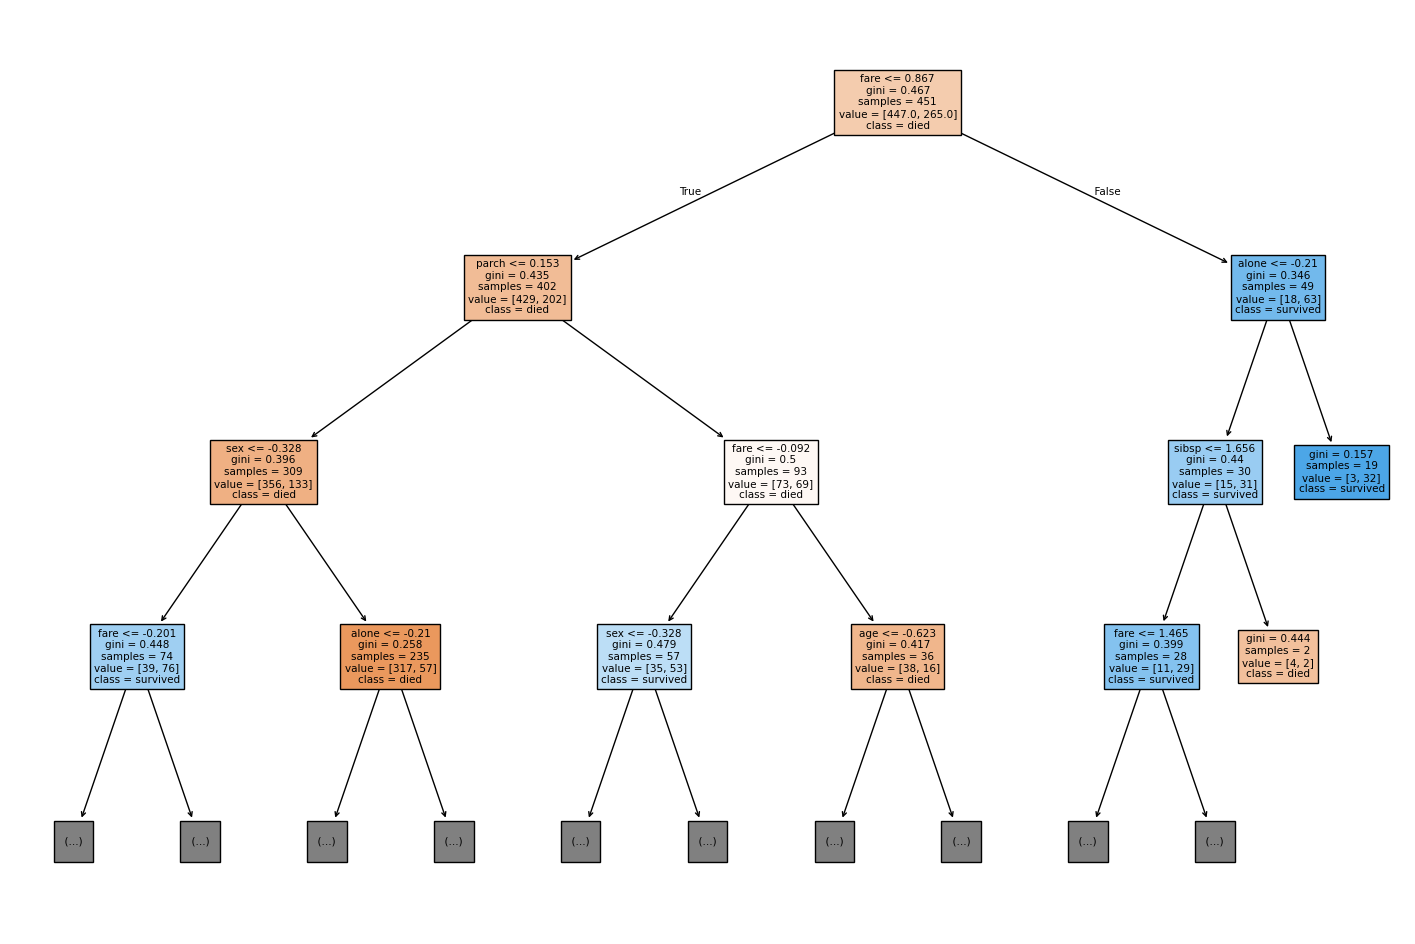

In [7]:
plt.figure(figsize=(18,12))

best_pipeline = rfc_model_cv.best_estimator_
best_model = best_pipeline.named_steps["rfc"]

# In normal decision tree we just build the tree after extracting the best model but here we had a random forest (multiple trees)
# by default we choose the first tree out of the 201 trees in the random forest
single_tree = best_model.estimators_[0]

plot_tree(
   single_tree,
   feature_names = X.columns,
   class_names = ["died","survived"],
   filled = True,
   max_depth = 3 
    
)

plt.show()

---
## <u>Bagging Classifier Comparison</u>

- bagging classifier can be done with any classication model we studied like knn, logistic regression etc but we try decision tree
- random forests and bagging classifier + decision tree classifier are exactly the same thing but with a difference:-
    - Bagging Classifier: Random rows + All features.
    - Random Forest: Random rows + Random features.

In [12]:
base_model = DecisionTreeClassifier()
bagging_model = BaggingClassifier(
    base_model, 
    n_estimators=201
)

bagging_model.fit(X_train, y_train)
y_pred = bagging_model.predict(X_test)

print("For bagging classifier + decision tree :-\n")
print("\nTest Accuracy : ", bagging_model.score(X_test, y_test))

For bagging classifier + decision tree :-


Test Accuracy :  0.8268156424581006
